In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Aim to solve du/dt = D * d^2u/dx^2, where D is the diffusion coefficient

def iter(u, D, x, dt):
    """Perform one iteration of the diffusion process."""
    dx = (x[-1] - x[0]) / len(x)
    d2u_dx2 = np.zeros_like(u)
    d2u_dx2[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / dx**2
    return u + D * d2u_dx2 * dt

def iter_nudge(u: list, D: float, x: list, t_idx: int, dt: float, 
               sensor_positions: list, sensor_data: list[list], lambda_nudge: float, sigma: float, debug = False):
    """Perform one iteration of the diffusion process with nudging."""
    uprime = iter(u, D, x, dt)
    
    # Nudge toward sensor data using Gaussian weighting around each sensor
    for pos, data_series in zip(sensor_positions, sensor_data):
        if debug:
            print(f"Sensor at {pos} has data {data_series[t_idx]} at time index {t_idx}")
        data = data_series[t_idx]
        gaussian = np.exp(-0.5 * ((x - pos) / sigma)**2)
        uprime += lambda_nudge * (data - u) * gaussian
        
    return uprime

In [46]:
# Simulate random data in time, data is taken at sparse sensor positions
time = np.arange(0, 100, 0.1)
sensor_positions = np.array([0, 25, 50, 75, 100])

sensor1_data = 1e-1 * np.abs(np.sin(0.1 * time) + np.random.randn(len(time)))
sensor2_data = 1e-1 * np.abs(np.sin(0.1 * time) + np.random.randn(len(time)))
sensor3_data = 1e-1 * np.abs(np.sin(0.1 * time) + np.random.randn(len(time)))
sensor4_data = 1e-1 * np.abs(np.sin(0.1 * time) + np.random.randn(len(time)))
sensor5_data = 1e-1 * np.abs(np.sin(0.1 * time) + np.random.randn(len(time)))

In [47]:
# Make an initial guess for the model state, let's just assume a gaussian centered at 50
x = np.linspace(0, 100, 101)
u0 = np.exp(-0.5 * ((x - 50) / 10)**2)  # Gaussian centered at 50 with width 10

dt = time[1] - time[0]

solution = []
solution.append(u0.copy())
# solve without nudging
u = u0.copy()
for i in range(len(time) - 1):
    u = iter(u, D=1.0, x=x, dt=dt)  # simple diffusion update 
    solution.append(u.copy())

solution = np.array(solution)

In [48]:
# Claude slop

def plot_time_evolution(x, time, solution, sensor_positions=None, sensor_data=None, num_snapshots=5):
    """
    Plot the time evolution of the diffusion process.
    
    Parameters:
    -----------
    x : array
        Spatial grid points
    time : array
        Time points
    solution : array
        Solution array with shape (n_timesteps, n_spatial_points)
    sensor_positions : array, optional
        Positions of sensors to mark on the plot
    sensor_data : list of arrays, optional
        List of sensor time series data, one array per sensor position
    num_snapshots : int
        Number of time snapshots to display
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left plot: Snapshots at different times
    time_indices = np.linspace(0, len(time) - 1, num_snapshots, dtype=int)
    colors = plt.cm.viridis(np.linspace(0, 1, num_snapshots))
    
    for idx, color in zip(time_indices, colors):
        axes[0].plot(x, solution[idx], label=f't = {time[idx]:.1f}', color=color, linewidth=2)
        
        # Plot sensor data as x marks at this timeslice
        if sensor_positions is not None and sensor_data is not None:
            for pos, data_series in zip(sensor_positions, sensor_data):
                axes[0].plot(pos, data_series[idx], 'x', color=color, markersize=10, 
                           markeredgewidth=2, markeredgecolor='black')
    
    if sensor_positions is not None:
        for pos in sensor_positions:
            axes[0].axvline(pos, color='red', linestyle='--', alpha=0.3, linewidth=1)
    
    axes[0].set_xlabel('Position (x)', fontsize=12)
    axes[0].set_ylabel('u(x, t)', fontsize=12)
    axes[0].set_title('Spatial Profiles at Different Times', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Right plot: Spacetime heatmap
    extent = [x[0], x[-1], time[0], time[-1]]
    im = axes[1].imshow(solution, aspect='auto', origin='lower', 
                        extent=extent, cmap='viridis', interpolation='bilinear')
    
    if sensor_positions is not None:
        for pos in sensor_positions:
            axes[1].axvline(pos, color='red', linestyle='--', alpha=0.5, linewidth=2)
    
    axes[1].set_xlabel('Position (x)', fontsize=12)
    axes[1].set_ylabel('Time (t)', fontsize=12)
    axes[1].set_title('Spacetime Evolution', fontsize=14)
    plt.colorbar(im, ax=axes[1], label='u(x, t)')
    
    plt.tight_layout()
    plt.show()

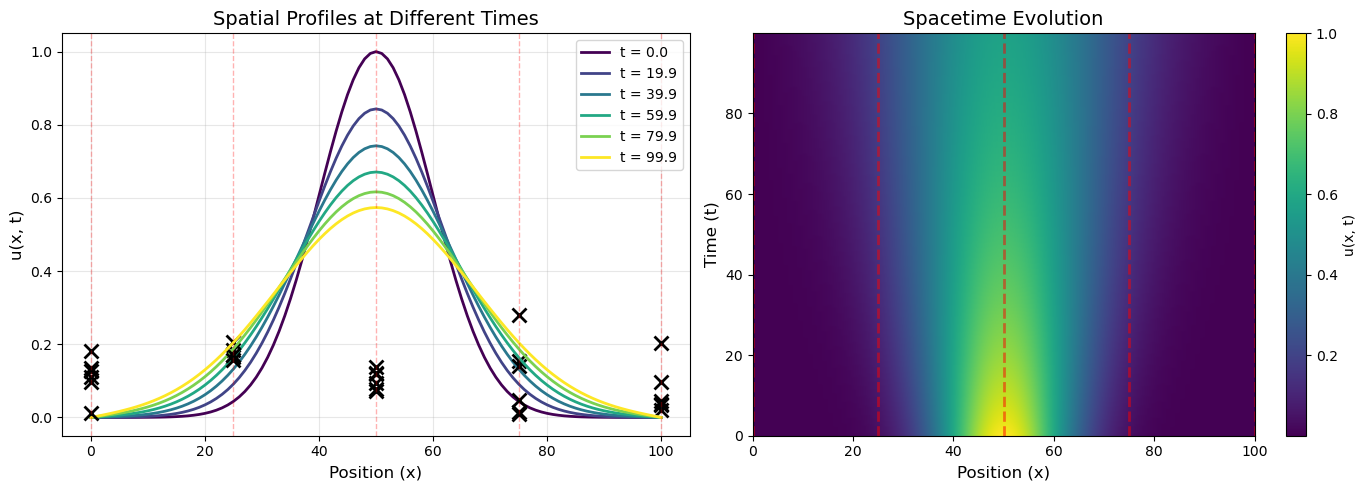

In [49]:
# Plot the time evolution
sensor_data_list = [sensor1_data, sensor2_data, sensor3_data, sensor4_data, sensor5_data]
plot_time_evolution(x, time, solution, sensor_positions=sensor_positions, 
                    sensor_data=sensor_data_list, num_snapshots=6)

In [54]:
# Now do the same but with nudging
x = np.linspace(0, 100, 101)
u0 = np.exp(-0.5 * ((x - 50) / 10)**2)

dt = time[1] - time[0]

solution = []
solution.append(u0.copy())
u = u0.copy()

sensor_data_list = [sensor1_data, sensor2_data, sensor3_data, sensor4_data, sensor5_data]
for i in range(len(time) - 1):
    u = iter_nudge(u, D=1.0, x=x, t_idx=i, dt=dt, sensor_positions = sensor_positions, sensor_data = sensor_data_list, lambda_nudge = 0.01, sigma = 5.0)  # simple diffusion update
    solution.append(u.copy())

solution = np.array(solution)

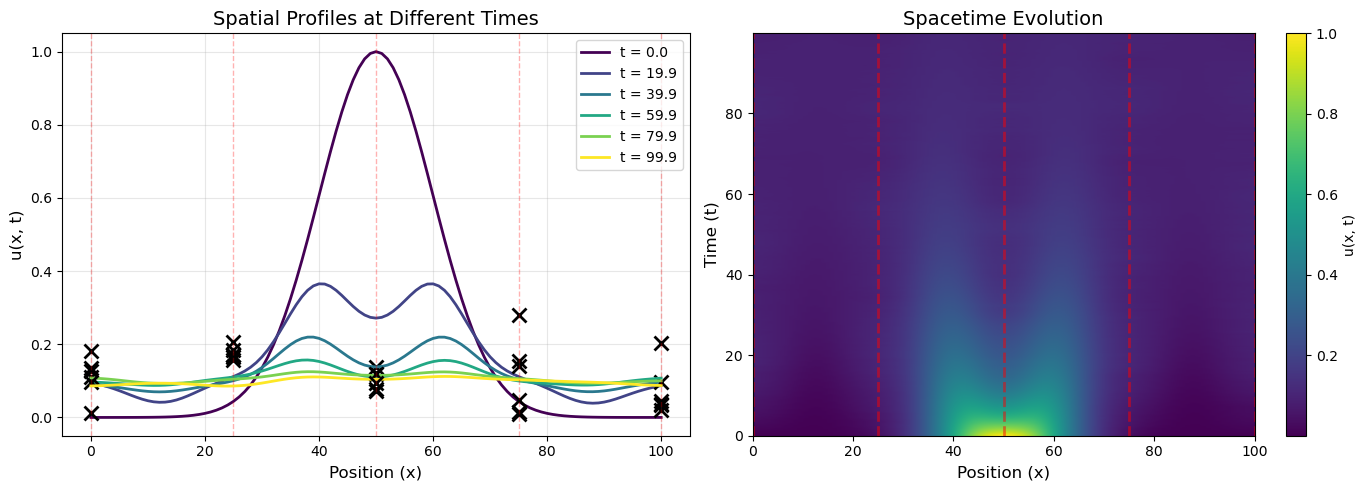

In [55]:
plot_time_evolution(x, time, solution, sensor_positions=sensor_positions, 
                    sensor_data=sensor_data_list, num_snapshots=6)